## Point plot for figure 4

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

df = pd.read_csv("hysteresis_summary_tauc.csv")
df.columns = df.columns.str.strip() # clean column name for spaces
print(df.head())

  event     SS   POC   DOC    PP   SRP  Turbidity  fDOM tauc
0   st1  0.785  0.74 -0.69  0.46 -0.04       0.58 -0.62   no
1   st2  0.174  0.20  0.02  0.15  0.07       0.13 -0.54  yes
2   st3  0.099  0.13 -0.54 -0.01 -0.09       0.09 -0.51  yes
3   st4  0.212  0.43 -0.18   NaN   NaN       0.15 -0.22  yes
4   st5  0.365  0.04  0.39   NaN   NaN       0.16  0.10   no


converting data to point plot format and separating by event type

In [10]:
# convert from wide to long format
constituents = ["SS", "POC", "DOC", "PP", "SRP", "Turbidity", "fDOM"]
for col in constituents:
    df[col] = pd.to_numeric(df[col], errors="coerce") # making sure hysteresis columns are numeric

# make sure tauc is clean text
df["tauc"] = df["tauc"].astype(str).str.strip().str.lower()

# reshape data the way seaborn likes it
df_long = df.melt(id_vars=["event", "tauc"], value_vars=constituents, var_name="constituent", value_name="HI")
# drop missing hysteresis values
df_long = df_long.dropna(subset=["HI"])
print(df_long.head())

# identify event type based on event name
df_long["event_type"] = np.where(df_long["event"].str.lower().str.startswith(("storm", "st")), "Summer storm", "Spring event")

# create viridis palette
viridis_colors = sns.color_palette("viridis", n_colors=len(constituents))
palette_dict = dict(zip(constituents, viridis_colors))

# marker symbols for event types
marker_dict = {"Summer storm": "o", "Spring event": "^"}

# alpha values for tauc condition
alpha_dict = {"yes": 0.99, "no": 0.56}

# numeric positions for each constituent
x_positions = {constituent: i for i, constituent in enumerate(constituents)}

# create one stable jittered x-position per data point
np.random.seed(42)

df_long["x_base"] = df_long["constituent"].map(x_positions).astype(float)

# This reproduces the original jitter structure:
# jitter was originally assigned by event_type only, not by tauc
df_long["x_jittered"] = np.nan

for event_type in marker_dict.keys():
    idx = df_long["event_type"] == event_type
    df_long.loc[idx, "x_jittered"] = (
        df_long.loc[idx, "x_base"] +
        np.random.uniform(-0.18, 0.18, size=idx.sum())
    )

  event tauc constituent     HI
0   st1   no          SS  0.785
1   st2  yes          SS  0.174
2   st3  yes          SS  0.099
3   st4  yes          SS  0.212
4   st5   no          SS  0.365


plot

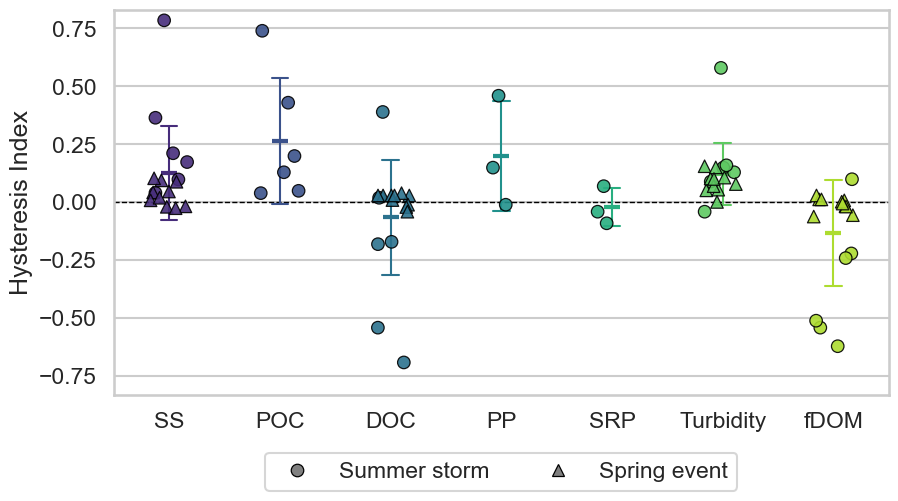

In [11]:
sns.set_theme(style="whitegrid", context="talk", rc={"axes.grid.axis": "y"})
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_axisbelow(True)

# individual HI values with: color = constituent and marker = event type
for event_type, marker in marker_dict.items():
    subset = df_long[df_long["event_type"] == event_type].copy()

    ax.scatter(subset["x_jittered"], subset["HI"], c=subset["constituent"].map(palette_dict), marker=marker, 
            alpha=0.9, edgecolor="black", linewidth=0.9, label=event_type, zorder=3)

# mean and standard deviation error bars
sns.pointplot(data=df_long, x="constituent", y="HI", hue="constituent", order=constituents, palette=palette_dict, estimator="mean", errorbar="sd",    
            linestyles="none", dodge=False, markers="_", markersize=12, capsize=0.15, legend=False, err_kws={"linewidth": 1.5}, ax=ax, zorder=2)
# zero reference line
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=1, zorder=1)

# axis formatting
ax.set_xticks(range(len(constituents)))
ax.set_xticklabels(constituents)
ax.set_xlabel("")
ax.set_ylabel("Hysteresis Index")

# symbol legend only
symbol_legend = [
    Line2D([0], [0], marker=marker_dict["Summer storm"], color="gray", linestyle="None", markersize=9, label="Summer storm", markeredgecolor="black", markeredgewidth=0.9),
    Line2D([0], [0], marker=marker_dict["Spring event"], color="gray", linestyle="None", markersize=9, label="Spring event", markeredgecolor="black", markeredgewidth=0.9)]

# place legend outside the plot, centered below the x-axis label
ax.legend(handles=symbol_legend, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)
# leave extra space at the bottom for the outside legend
ax.set_ylim(-0.83, 0.83)
#plt.tight_layout()
#fig.subplots_adjust(bottom=0.28)
plt.savefig("figure4.png", dpi=400, bbox_inches="tight")
plt.show()

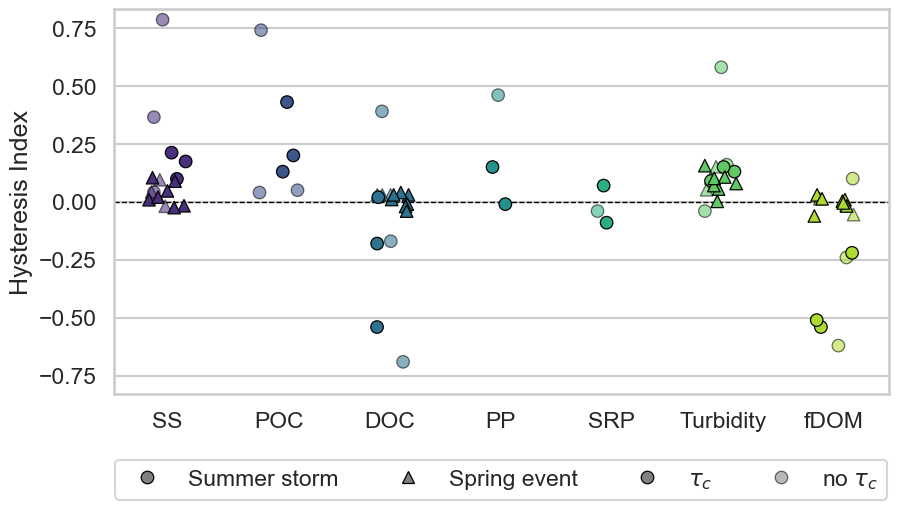

In [14]:
sns.set_theme(style="whitegrid", context="talk", rc={"axes.grid.axis": "y"})
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_axisbelow(True)

# plot raw points
for event_type, marker in marker_dict.items():
    for tauc_value in ["no", "yes"]:   # plot faded first, highlighted second
        subset = df_long[(df_long["event_type"] == event_type) & (df_long["tauc"] == tauc_value)].copy()
        ax.scatter(subset["x_jittered"], subset["HI"], c=subset["constituent"].map(palette_dict), marker=marker,
            alpha=alpha_dict[tauc_value], edgecolor="black", linewidth=0.9, zorder=3 if tauc_value == "yes" else 2)

# zero reference line
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=1, zorder=1)

# axis formatting
ax.set_xticks(range(len(constituents)))
ax.set_xticklabels(constituents)
ax.set_xlabel("")
ax.set_ylabel("Hysteresis Index")

# legend for event type (marker shape)
symbol_legend = [
    Line2D([0], [0], marker=marker_dict["Summer storm"], color="gray", markerfacecolor="gray", linestyle="None", markersize=9, label="Summer storm", markeredgecolor="black", markeredgewidth=0.9),
    Line2D([0], [0], marker=marker_dict["Spring event"], color="gray", markerfacecolor="gray", linestyle="None", markersize=9, label="Spring event", markeredgecolor="black", markeredgewidth=0.9)]

# Legend for tauc highlighting
alpha_legend = [
    Line2D([0], [0], marker="o", color="gray", markerfacecolor="gray", linestyle="None", alpha=alpha_dict["yes"], markersize=9, label=r"$\tau_c$", markeredgecolor="black", markeredgewidth=0.9),
    Line2D([0], [0], marker="o", color="gray", markerfacecolor="gray", linestyle="None", alpha=alpha_dict["no"], markersize=9, label=r"no $\tau_c$", markeredgecolor="black", markeredgewidth=0.9)]

# combine both legends into one
combined_legend = symbol_legend + alpha_legend
ax.legend(handles=combined_legend, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=4, frameon=True)
# leave extra space at the bottom for the outside legend
ax.set_ylim(-0.83, 0.83)
#plt.tight_layout()
#fig.subplots_adjust(bottom=0.30)
plt.savefig("figure5.png", dpi=400, bbox_inches="tight")
plt.show()